In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cmocean.cm as cm

In [2]:
CanWWTP_file = "data/output/CanWWTP_20260715.nc"

ds = xr.open_dataset(CanWWTP_file)

#### Dataset summary

In [3]:
print(ds)

print()

print("Variables")
for var in ds.data_vars:
    print("  ", var)

print()

print("Dimensions")
print(ds.dims)

print()

print("Attributes")
for key, value in ds.attrs.items():
    print(f"{key}: {value}")

<xarray.Dataset> Size: 520MB
Dimensions:          (y: 898, x: 398, time_counter: 12)
Coordinates:
  * y                (y) int64 7kB 0 1 2 3 4 5 6 ... 891 892 893 894 895 896 897
  * x                (x) int64 3kB 0 1 2 3 4 5 6 ... 391 392 393 394 395 396 397
  * time_counter     (time_counter) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 1MB ...
    nav_lon          (y, x) float32 1MB ...
    area             (y, x) float64 3MB ...
    flux             (time_counter, y, x) float64 34MB ...
    temperature      (time_counter, y, x) float64 34MB ...
    NO3              (time_counter, y, x) float64 34MB ...
    ...               ...
    DON              (time_counter, y, x) float64 34MB ...
    bSi              (time_counter, y, x) float64 34MB ...
    oxygen           (time_counter, y, x) float64 34MB ...
    alkalinity       (time_counter, y, x) float64 34MB ...
    DIC              (time_counter, y, x) float64 34MB ...
    turb      

/tmp/ipykernel_647755/3933490684.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = plt.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


Text(0.5, 1.0, 'Canadian WWTP Locations (except Iona)')

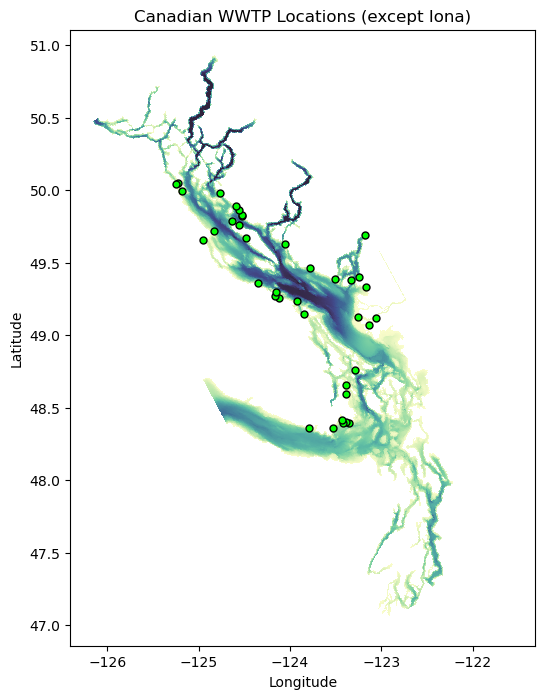

In [14]:
bathy = xr.open_dataset("/ocean/atall/MOAD/grid/bathymetry_202108.nc")
bathy_data = bathy["Bathymetry"]
lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]

flux = ds["flux"][0].values

j, i = np.where(flux > 0)

plt.figure(figsize=(6,8))

mesh = plt.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
plt.scatter(
    ds["nav_lon"].values[j,i],
    ds["nav_lat"].values[j,i],
    color="lime",
    edgecolor="black",
    s=25,
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Canadian WWTP Locations (except Iona)")


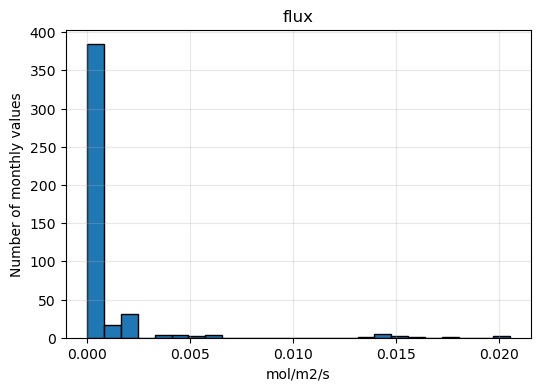

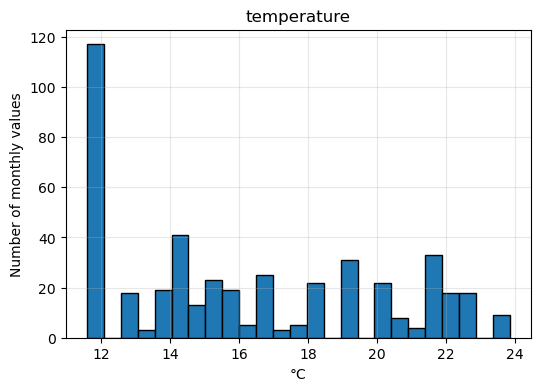

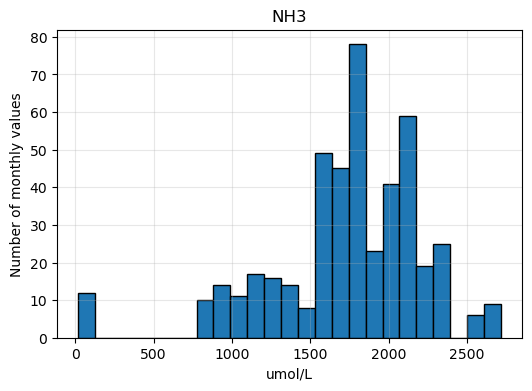

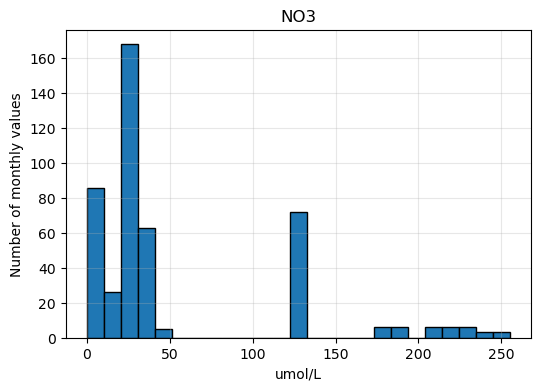

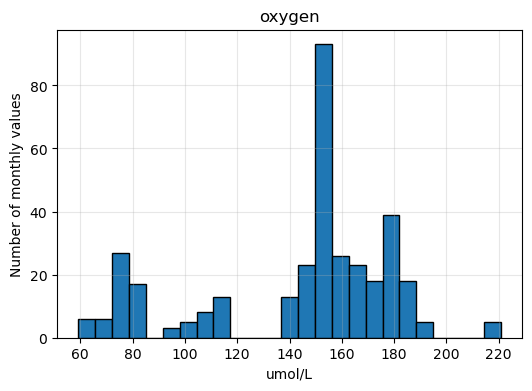

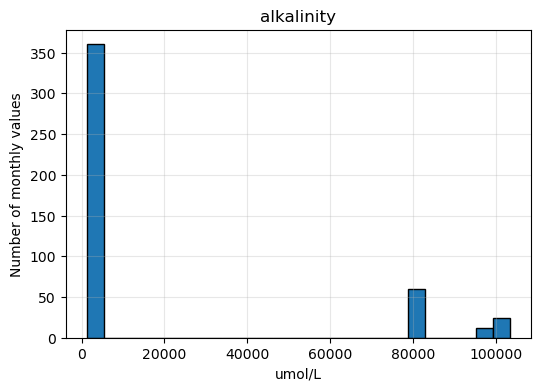

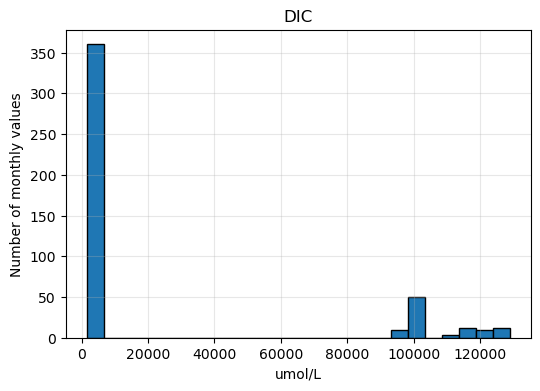

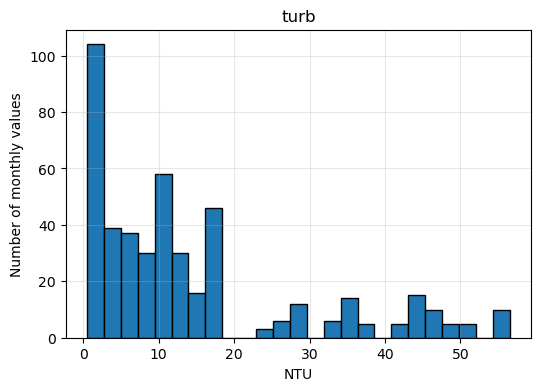

In [16]:
for var in variables:

    x = ds[var].values

    x = x[x > 0]

    plt.figure(figsize=(6,4))

    plt.hist(x, bins=25, edgecolor="black")

    plt.xlabel(ds[var].units)
    plt.ylabel("Number of monthly values")
    plt.title(var)

    plt.grid(alpha=0.3)

In [30]:
station_names = {
    (428, 302): ["Annacis"],
    (428, 302): ["Lulu"],
    (462, 340): ["Lions Gate"],
    (411, 331): ["Riverport"],

    (297, 193): ["McLoughlin Point"],
    (294, 196): ["Clover Point"],
    (298, 187): ["Macaulay Point"],
    (347, 225): ["Saanich Peninsula"],
    (360, 251): ["Magic Lake"],
    (299, 166): ["William Head"],

    (497, 217): ["Greater Nanaimo"],
    (551, 171): ["French Creek"],
    (525, 191): ["Nanoose Bay"],
    (474, 217): ["Duke Point"],

    (749, 124): ["Campbell River STP"],
    (652, 119): ["Cumberland"],
    (497, 298): ["Town of Gibsons"],
    (533, 386): ["Squamish"],
    (531, 268): ["Sechelt Water Resource Centre"],
    (318, 128): ["Sooke"],
    (656, 144): ["Comox-Strathcona Regional District STP"],

    (654, 202): ["Westview"],
    (665, 203): ["Powell River Townsite"],
    (702, 187): ["Lund"],
    (656, 204): ["Wildwood"],
    (622, 190): ["Gillies Bay"],
    (645, 190): ["Van Anda"],

    (484, 323): ["Snug Cove (Bowen Island)"],
    (481, 338): ["Citrus Wynd"],
    (583, 249): ["Sundowner"],
    (748, 128): ["Quathiaski Cove (Quadra Island)"],

    (672, 201): ["Sliammon (Tla'amin)"],
    (521, 186): ["Nanoose FN"],
    (335, 217): ["Tsawout"],
    (515, 191): ["Snaw-Naw-As"],
    (735, 127): ["Cape Mudge Band (We Wai Kai)"],
    (409, 314): ["TFN Sewage (Tsawwassen)"],

    (303, 188): ["CFB Esquimalt / Rocky Point"],
    (655, 183): ["BC Ferries Terminals"],
}

In [33]:
def station_plots(ds, output):

    figdir=output/"stations"

    figdir.mkdir(exist_ok=True)

    variables=[

        "flux",
        "temperature",
        "NH3",
        "NO3",
        "oxygen",
        "alkalinity",
        "DIC",
        "PON",
        "DON",
        "turb",

    ]

    flux=ds["flux"][0].values

    jj,ii=np.where(flux>0)

    for j,i in zip(jj,ii):

        fig,axs=plt.subplots(

            5,

            2,

            figsize=(12,13),

        )

        axs=axs.ravel()

        for ax,var in zip(axs,variables):

            ax.plot(

                np.arange(1,13),

                ds[var][:,j,i],

                "-o",

            )

            ax.set_title(var)

            ax.grid()

        plt.tight_layout()

        names = station_names.get((j, i), [f"{j}_{i}"])

        for name in names:

            filename = (
                name
                .replace("/", "-")
                .replace(" ", "_")
                .replace("(", "")
                .replace(")", "")
            )

            fig.suptitle(name, fontsize=16)

            plt.savefig(figdir / f"{filename}_jj{j}_ii{i}.png")

        plt.close()

In [34]:
output = Path("validation")

output.mkdir(exist_ok=True)

station_plots(ds, output)